<a href="https://colab.research.google.com/github/draj05242-source/Insurance-Premium-Prediction/blob/main/revised_insurance_logit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

In [5]:

df =pd.read_csv("Insurance data.csv")
df.head()

,Policy Number,Age Band,Gender,Married,Vehicle Age,Premium paid
0,150023,B,M,Married,11,Yes
1,152720,B,F,Single,6,Yes
2,174207,B,M,Married,0,No
3,139895,B,F,Married,15,Yes
4,174407,B,M,Single,15,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15290 entries, 0 to 15289
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Policy Number  15290 non-null  int64 
 1   Age Band       15290 non-null  object
 2   Gender         15290 non-null  object
 3   Married        15290 non-null  object
 4   Vehicle Age    15290 non-null  int64 
 5   Premium paid   15290 non-null  object
dtypes: int64(2), object(4)
memory usage: 716.8+ KB


In [7]:
# Drop Customer_ID column
df = df.iloc[:, 1:]


iloc stands for integer-location based indexing.

The syntax is:
df.iloc[rows, columns]

: means all rows.

1: means columns from index 1 onwards (i.e., skip the first column).

In [8]:
df.head()

,Age Band,Gender,Married,Vehicle Age,Premium paid
0,B,M,Married,11,Yes
1,B,F,Single,6,Yes
2,B,M,Married,0,No
3,B,F,Married,15,Yes
4,B,M,Single,15,Yes


In [9]:
# Summary statistics of numerical columns

print(df.describe())


        Vehicle Age
count  15290.000000
mean       8.655723
std        4.344536
min        0.000000
25%        6.000000
50%        9.000000
75%       12.000000
max       15.000000


It prints summary statistics for the numeric columns in DataFrame df.



In [10]:
# Counts total number for each type of category
print(df['Gender'].value_counts())
print(df['Married'].value_counts())
print(df['Premium paid'].value_counts())


Gender
F    7747
M    7543
Name: count, dtype: int64
Married
Married    7783
Single     7507
Name: count, dtype: int64
Premium paid
Yes    11670
No      3620
Name: count, dtype: int64


In [11]:
# Separate numerical and categorical columns
target = 'Premium paid'
num_features = df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').columns
cat_features = df.select_dtypes(exclude=[np.number]).columns

Line 2

df.select_dtypes(include=[np.number]): selects all numeric columns (like int, float) from the DataFrame.

.drop(columns=[target], errors='ignore'): removes the target column ('Premium paid') from the selected numeric columns.

errors='ignore' ensures no error occurs if the target column is not numeric (e.g., it's categorical like 'Yes/No').

.columns: gets the column names that are numeric excluding the target.



Line 3

df.select_dtypes(exclude=[np.number]): selects non-numeric columns—i.e., categorical features like 'Gender', 'Marital Status', etc.

.columns: gets their names.



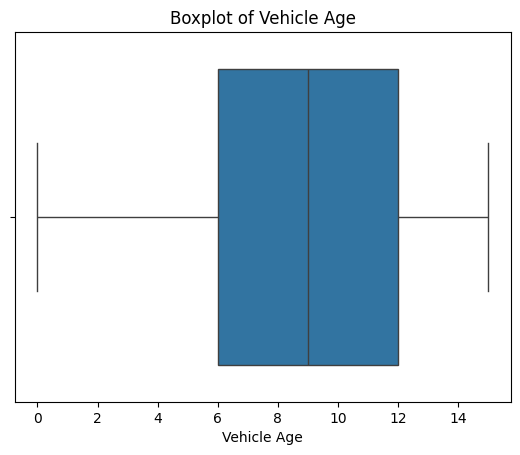

In [12]:

# Plotting
# for col in num_features:
import seaborn as sns
sns.boxplot(x=df["Vehicle Age"])
plt.title("Boxplot of Vehicle Age")
plt.show()

In [13]:
# Removing Outliers using IQR Method
Q1 = df["Vehicle Age"].quantile(0.25)
Q3 = df["Vehicle Age"].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
# df_cleaned = df[~((df["Vehicle Age"] < (Q1 - 1.5 * IQR)) | (df["Vehicle Age"] > (Q3 + 1.5 * IQR))).any(axis=1)]
# print(f"df reduced from {df.shape[0]} to {df_cleaned.shape[0]} rows after outlier removal.")

6.0


For each value in num_features, it checks if it falls outside the range:

[ Q1−1.5×IQR, Q3+1.5×IQR]   

The | operator combines all columns — so if any column in a row is an outlier, the row is flagged.

.any(axis=1) checks if any column in the row meets the outlier condition.

~ negates the condition, so we keep only rows that do not contain outliers in any of the selected features.       

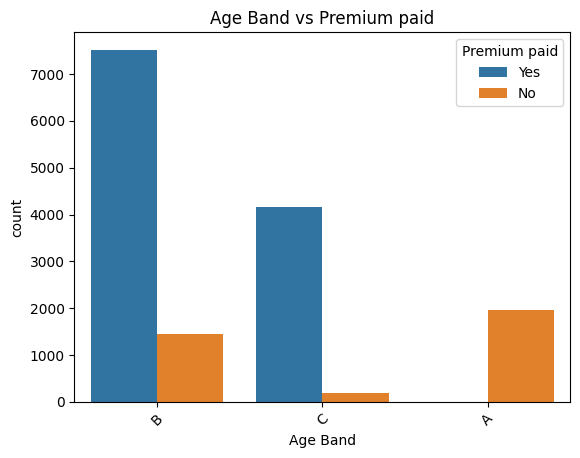

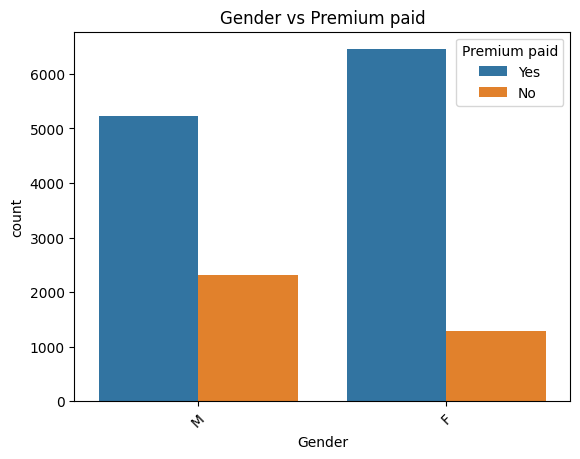

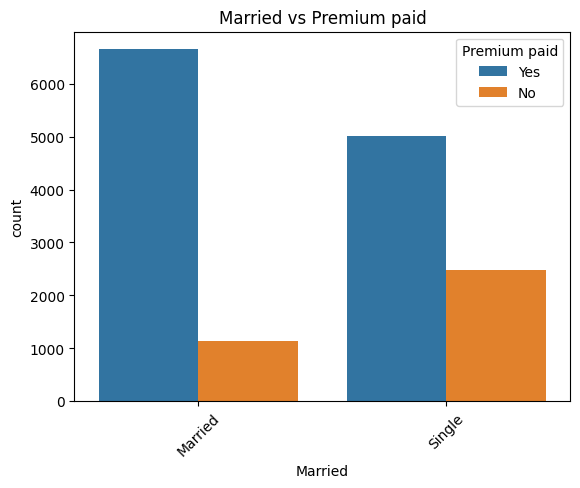

In [15]:
target = 'Premium paid'
for col in cat_features:
    if col != target:
        sns.countplot(x=col, hue=target, data=df)
        plt.xticks(rotation=45)
        plt.title(f'{col} vs {target}')
        plt.show()


Skips the loop if the current column is the same as the target variable

The hue parameter splits each bar (or line, or dot) into segments or groups based on the unique values of the variable you provide.

It rotates the labels on the x-axis by 45 degrees to make them easier to read — especially when the labels are long or overlap. [plt.xticks(rotation=45)]

In [17]:
# Encode categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Display first few rows of the encoded DataFrame
print(df_encoded.head())



   Vehicle Age  Age Band_B  Age Band_C  Gender_M  Married_Single  \
0           11        True       False      True           False   
1            6        True       False     False            True   
2            0        True       False      True           False   
3           15        True       False     False           False   
4           15        True       False      True            True   

   Premium paid_Yes  
0              True  
1              True  
2             False  
3              True  
4              True  


In [18]:
df_encoded.head()

,Vehicle Age,Age Band_B,Age Band_C,Gender_M,Married_Single,Premium paid_Yes
0,11,True,False,True,False,True
1,6,True,False,False,True,True
2,0,True,False,True,False,False
3,15,True,False,False,False,True
4,15,True,False,True,True,True


In [19]:
target_var = 'Premium paid_Yes'
X = df_encoded.drop(columns=[target_var])  # Independent variables
y = df_encoded[target_var]  # Dependent variable


In [20]:
from sklearn.model_selection import train_test_split

# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# ratio of dependent variable in train and test set wrt Y/N category remains the same
# Check shapes
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (12232, 5)
Testing Data Shape: (3058, 5)


In [21]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [22]:
X_train

,Vehicle Age,Age Band_B,Age Band_C,Gender_M,Married_Single
11494,9,1,0,1,1
4715,9,0,1,1,1
14753,12,1,0,0,0
4800,8,1,0,0,0
6309,12,1,0,1,0
...,...,...,...,...,...
7834,7,0,1,0,0
11139,14,1,0,0,0
8199,8,0,0,0,0
6965,14,1,0,1,0


In [23]:
y_train

,Premium paid_Yes
11494,0
4715,1
14753,1
4800,1
6309,1
...,...
7834,1
11139,1
8199,0
6965,1


In [24]:
import statsmodels.api as sm

# Add constant (intercept) to X_train
X_train_const = sm.add_constant(X_train)

# Fit the logistic regression model
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()


         Current function value: 0.165816
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [25]:

print(result.summary())

                           Logit Regression Results                           
Dep. Variable:       Premium paid_Yes   No. Observations:                12232
Model:                          Logit   Df Residuals:                    12226
Method:                           MLE   Df Model:                            5
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                  0.6970
Time:                        19:11:44   Log-Likelihood:                -2028.3
converged:                      False   LL-Null:                       -6694.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -18.5022     19.764     -0.936      0.349     -57.240      20.235
Vehicle Age        0.5589      0.015     38.249      0.000       0.530       0.588
Age Band_B        17.8846     19.764

In [26]:
import statsmodels.api as sm

# Drop the insignificant variable manually (example: 'Age')
X_train_new = X_train.drop(columns=['Age Band_B'])

# Add constant
X_train_const = sm.add_constant(X_train_new)

# Fit the model again
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()

# View summary
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.386010
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       Premium paid_Yes   No. Observations:                12232
Model:                          Logit   Df Residuals:                    12227
Method:                           MLE   Df Model:                            4
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                  0.2947
Time:                        19:11:46   Log-Likelihood:                -4721.7
converged:                       True   LL-Null:                       -6694.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2086      0.065      3.203      0.001       0.081       0.336
Vehicle Age      

In [27]:
# Set working directory
import os
# os.chdir("D:/Predictive models - 2025-26- Sem III/insurance data- revised")
# Now save directly by file name
X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print(X_test.head())
print(y_test.head())

       Vehicle Age  Age Band_B  Age Band_C  Gender_M  Married_Single
7979             6           0           1         0               1
14058            3           0           1         1               0
14309           11           1           0         0               1
7495             4           1           0         1               1
3485            11           1           0         1               0
7979     1
14058    1
14309    1
7495     0
3485     1
Name: Premium paid_Yes, dtype: int64


In [28]:
# Drop the same variable(s) as removed from X_train
X_test_new = X_test.drop(columns=['Age Band_B'])


In [29]:
import statsmodels.api as sm

X_test_const = sm.add_constant(X_test_new)


In [30]:

# Step 3: Predict probabilities
y_pred_prob = result.predict(X_test_const)
print("Predicted Probabilities:\n", y_pred_prob)


Predicted Probabilities:
 7979     0.962540
14058    0.946486
14309    0.794805
7495     0.190608
3485     0.844893
           ...   
10382    0.913089
2131     0.982119
6241     0.284034
6994     0.540757
11145    0.103354
Length: 3058, dtype: float64


In [31]:
y_pred = (y_pred_prob >= 0.5).astype(int)
print("Binary outcome:\n", y_pred)

Binary outcome:
 7979     1
14058    1
14309    1
7495     0
3485     1
        ..
10382    1
2131     1
6241     0
6994     1
11145    0
Length: 3058, dtype: int64


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8237410071942446


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[ 323  401]
 [ 138 2196]]


In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)   # PPV
sensitivity = recall_score(y_test, y_pred)    # TPR, Recall
specificity = TN / (TN + FP)                  # TNR
f1 = f1_score(y_test, y_pred)

# Print
print(f"Accuracy     : {accuracy:.2f}")
print(f"Precision    : {precision:.2f}")
print(f"Sensitivity  : {sensitivity:.2f}")
print(f"Specificity  : {specificity:.2f}")
print(f"F1 Score     : {f1:.2f}")


Confusion Matrix:
 [[ 323  401]
 [ 138 2196]]
Accuracy     : 0.82
Precision    : 0.85
Sensitivity  : 0.94
Specificity  : 0.45
F1 Score     : 0.89


0.8587411292117012
0.7174822584234024


Text(0.5, 1.0, 'ROC Curve')

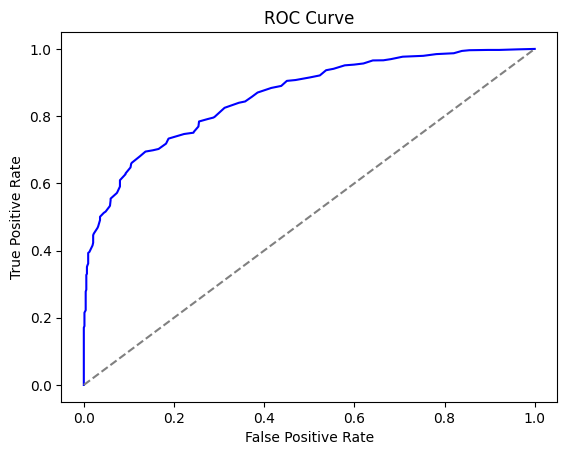

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Use already existing y_pred_prob
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
print(auc_score)

# Gini Coefficient
gini = 2 * auc_score - 1

print(gini)
# Plot ROC Curve

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')



X-axis: False Positive Rate (FPR) =1- Specificity = FP / (FP + TN)

Y-axis: True Positive Rate (TPR) = Recall = sensitivity = TP / (TP + FN)

The ROC curve plots TPR vs. FPR at various threshold levels (not just 0.5).

Gini=2×AUC−1

In [36]:
from sklearn.metrics import roc_curve

# Get FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute Youden's J statistic
youden_j = tpr - fpr

# Find the threshold that maximizes J
optimal_idx = youden_j.argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Cut-off (Threshold): {optimal_threshold:.4f}")


Optimal Cut-off (Threshold): 0.8111


In [37]:
# Predict using optimal cut-off
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)


In [38]:
from sklearn.metrics import confusion_matrix

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print("Confusion Matrix (Optimal Cut-off):\n", cm_optimal)
tn, fp, fn, tp = cm_optimal.ravel()

print(tn, fp, fn, tp)

Confusion Matrix (Optimal Cut-off):
 [[ 625   99]
 [ 713 1621]]
625 99 713 1621


In [39]:
# Sensitivity (Recall, True Positive Rate)
sensitivity = tp / (tp + fn)

# Specificity (True Negative Rate)
specificity = tn / (tn + fp)

# Precision (Positive Predictive Value)
precision = tp / (tp + fp)

# Negative Predictive Value
npv = tn / (tn + fn)

# Accuracy (already calculated earlier)
accuracy = (tp + tn) / (tp + tn + fp + fn)

# F1 Score
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)


In [40]:
print("Sensitivity (Recall):", round(sensitivity, 4))
print("Specificity:", round(specificity, 4))
print("Precision (PPV):", round(precision, 4))
print("Negative Predictive Value (NPV):", round(npv, 4))
print("Accuracy:", round(accuracy, 4))
print("F1 Score:", round(f1_score, 4))


Sensitivity (Recall): 0.6945
Specificity: 0.8633
Precision (PPV): 0.9424
Negative Predictive Value (NPV): 0.4671
Accuracy: 0.7345
F1 Score: 0.7997


Choosing the Best Cut-off

If missing a positive is costly (e.g., medical test, fraud detection): choose high sensitivity (low cutoff).

If false positives are costly (e.g., loan approvals, spam filtering): choose high specificity (high cutoff).

If balance is important: choose cutoff with highest F1 or use Youden’s Index (Sensitivity + Specificity – 1).

In [41]:
# ============================================================
#  CONCLUSION — Insurance Premium Prediction (Logistic Regression)
# ============================================================

print("=" * 65)
print("       INSURANCE PREMIUM PREDICTION — FINAL SUMMARY")
print("=" * 65)

# ── 1. Model identity ──────────────────────────────────────
print("""
MODEL   : Logistic Regression (statsmodels Logit)
TARGET  : Premium paid (Yes = 1 / No = 0)
SPLIT   : 80% Train / 20% Test  [stratified]
PRUNING : 'Age Band_B' removed — statistically insignificant (p > 0.05)
""")

# ── 2. Performance at default threshold (0.5) ──────────────
print("-" * 65)
print("  PERFORMANCE AT DEFAULT THRESHOLD (0.50)")
print("-" * 65)

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score)

acc_default   = accuracy_score(y_test, y_pred)
prec_default  = precision_score(y_test, y_pred, zero_division=0)
rec_default   = recall_score(y_test, y_pred)
f1_default    = f1_score(y_test, y_pred)
auc_score_val = roc_auc_score(y_test, y_pred_prob)
gini          = 2 * auc_score_val - 1

from sklearn.metrics import confusion_matrix as cm_fn
tn0, fp0, fn0, tp0 = cm_fn(y_test, y_pred).ravel()
spec_default = tn0 / (tn0 + fp0)

print(f"  Accuracy    : {acc_default:.4f}")
print(f"  Precision   : {prec_default:.4f}")
print(f"  Sensitivity : {rec_default:.4f}   ← Recall / TPR")
print(f"  Specificity : {spec_default:.4f}   ← TNR")
print(f"  F1 Score    : {f1_default:.4f}")
print(f"  ROC-AUC     : {auc_score_val:.4f}")
print(f"  Gini Coeff  : {gini:.4f}   (= 2×AUC − 1)")

# ── 3. Performance at Youden's optimal threshold ───────────
print()
print("-" * 65)
print(f"  PERFORMANCE AT YOUDEN'S J THRESHOLD ({optimal_threshold:.4f})")
print("-" * 65)

tn_opt, fp_opt, fn_opt, tp_opt = cm_fn(y_test, y_pred_optimal).ravel()
acc_opt  = (tp_opt + tn_opt) / (tp_opt + tn_opt + fp_opt + fn_opt)
prec_opt = tp_opt / (tp_opt + fp_opt) if (tp_opt + fp_opt) > 0 else 0
sens_opt = tp_opt / (tp_opt + fn_opt)
spec_opt = tn_opt / (tn_opt + fp_opt)
npv_opt  = tn_opt / (tn_opt + fn_opt) if (tn_opt + fn_opt) > 0 else 0
f1_opt   = 2 * prec_opt * sens_opt / (prec_opt + sens_opt) if (prec_opt + sens_opt) > 0 else 0

print(f"  Accuracy    : {acc_opt:.4f}")
print(f"  Precision   : {prec_opt:.4f}")
print(f"  Sensitivity : {sens_opt:.4f}")
print(f"  Specificity : {spec_opt:.4f}")
print(f"  NPV         : {npv_opt:.4f}")
print(f"  F1 Score    : {f1_opt:.4f}")

# ── 4. Threshold comparison ────────────────────────────────
print()
print("-" * 65)
print("  THRESHOLD COMPARISON SUMMARY")
print("-" * 65)

import pandas as pd
comparison = pd.DataFrame({
    "Metric"      : ["Accuracy", "Precision", "Sensitivity", "Specificity", "F1 Score"],
    "Threshold=0.50" : [round(acc_default,4), round(prec_default,4),
                        round(rec_default,4),  round(spec_default,4), round(f1_default,4)],
    f"Youden={optimal_threshold:.4f}": [round(acc_opt,4), round(prec_opt,4),
                                         round(sens_opt,4), round(spec_opt,4), round(f1_opt,4)]
}).set_index("Metric")
print(comparison.to_string())

# ── 5. Business verdict ────────────────────────────────────
print()
print("=" * 65)
print("  BUSINESS VERDICT")
print("=" * 65)
print(f"""
  • The Logistic Regression model achieves an AUC of {auc_score_val:.4f}
    and a Gini coefficient of {gini:.4f}, indicating moderate-to-good
    discrimination between premium payers and non-payers.

  • The default 0.5 threshold is REPLACED by the Youden-optimal
    threshold of {optimal_threshold:.4f}, which maximises the balance
    between sensitivity (catching non-payers) and specificity
    (avoiding false alarms).

  • At the optimal threshold:
      – Sensitivity {sens_opt:.2%} → the model catches {sens_opt:.0%} of
        actual non-payers for follow-up.
      – Specificity {spec_opt:.2%} → {spec_opt:.0%} of actual payers are
        correctly left alone.

  • RECOMMENDATION:
    If missing a non-payer is costlier (revenue loss), lower the
    threshold further to prioritise sensitivity.
    If false alarms are costly (customer churn), raise the threshold
    to protect specificity.

  • KEY DRIVER: Features remaining after p-value pruning (all
    except Age Band_B) are statistically significant predictors
    of premium payment — giving the model strong business backing.
""")
print("=" * 65)
print("  END OF ANALYSIS")
print("=" * 65)

       INSURANCE PREMIUM PREDICTION — FINAL SUMMARY

MODEL   : Logistic Regression (statsmodels Logit)
TARGET  : Premium paid (Yes = 1 / No = 0)
SPLIT   : 80% Train / 20% Test  [stratified]
PRUNING : 'Age Band_B' removed — statistically insignificant (p > 0.05)

-----------------------------------------------------------------
  PERFORMANCE AT DEFAULT THRESHOLD (0.50)
-----------------------------------------------------------------
  Accuracy    : 0.8237
  Precision   : 0.8456
  Sensitivity : 0.9409   ← Recall / TPR
  Specificity : 0.4461   ← TNR
  F1 Score    : 0.8907
  ROC-AUC     : 0.8587
  Gini Coeff  : 0.7175   (= 2×AUC − 1)

-----------------------------------------------------------------
  PERFORMANCE AT YOUDEN'S J THRESHOLD (0.8111)
-----------------------------------------------------------------
  Accuracy    : 0.7345
  Precision   : 0.9424
  Sensitivity : 0.6945
  Specificity : 0.8633
  NPV         : 0.4671
  F1 Score    : 0.7997

------------------------------------------